# Poisson Disk Corrector — Pipeline Smoke Test

End-to-end walkthrough of every pipeline component, in order. Each section
is independently executable; later sections build on earlier ones.

| Section | Component | File |
|---|---|---|
| 1 | Data generation | `data/data_generator.py` |
| 2 | Preprocessing | `data/data_processor.py` |
| 3 | Training (optional) | `training/trainer.py` |
| 4 | Model forward pass | `models/fixed_rd/model9.py` |
| 5 | SPH data | `inference/sph_data/` |
| 6 | Tiling config | `inference/pipeline/tiling.py` |
| 7 | Ghost buffer / PBC | `inference/pipeline/pbc.py` |
| 8 | Coordinate scaling | `inference/pipeline/scaling.py` |
| 9 | Full corrector | `inference/pipeline/corrector.py` |
| 10 | Visualisation | `inference/visualization/comparison.py` |

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path

ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)   # ensure all relative YAML/data paths resolve correctly

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 9})

print(f'Project root : {ROOT}')
print(f'PyTorch      : {torch.__version__}')
print(f'CUDA         : {torch.cuda.is_available()}')


Project root : E:\VSCode\CorrectorWorkshop
PyTorch      : 2.12.0+cu126
CUDA         : True


## 1 — Data generation

`PoissonDiskDataset` and `PackedPoissonDiskDataset` generate clouds **online** (per batch, no file). The packed variant is parameterised by `packedness` (fraction of theoretical max density), making difficulty independent of `rd`.

Sparse  N = 50
Packed  N_target = 231
Batch shape: (4, 231, 2)


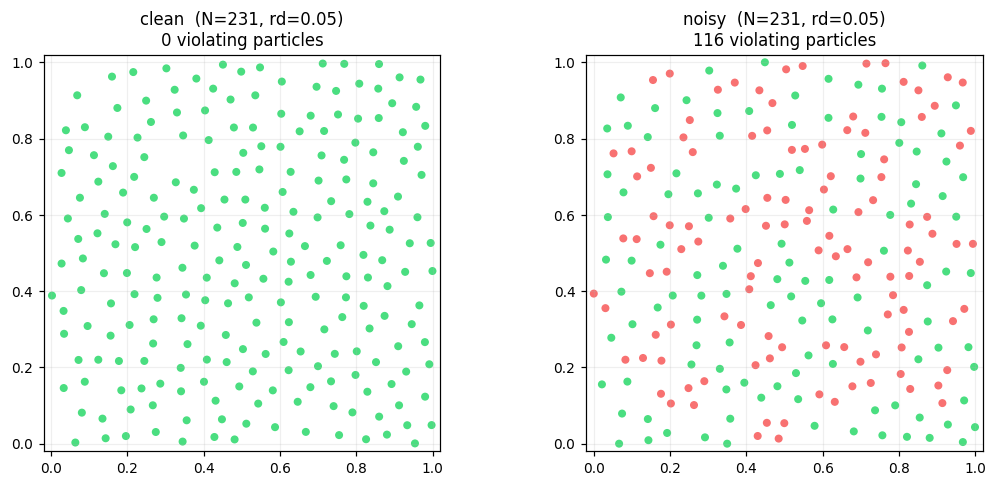

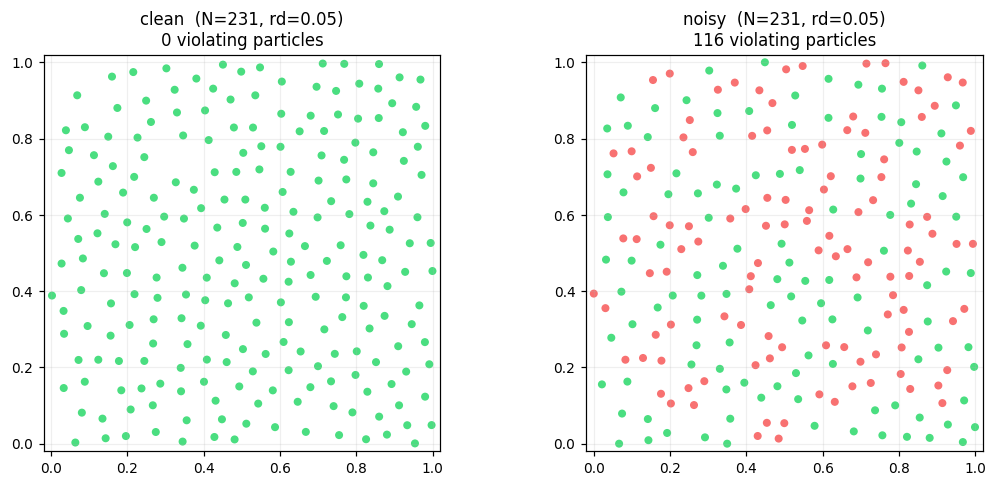

In [2]:
from data.data_generator import PoissonDiskDataset, PackedPoissonDiskDataset
from inference.visualization.training import plot_cloud_pair

ds_sparse = PoissonDiskDataset(dim=2, cardinality=50, rd=0.05, seed=42,
                               noise_scale_min=0.0, noise_scale_max=0.02)
ds_packed = PackedPoissonDiskDataset(dim=2, rd=0.05, packedness=0.5, seed=42,
                                     noise_scale_min=0.0, noise_scale_max=0.02)
print(f'Sparse  N = {ds_sparse.cardinality}')
print(f'Packed  N_target = {ds_packed.n_target}')

clean = ds_packed.generate_sample(batch_size=4)  # (4, N, 2)
noisy = ds_packed.noise_sample(clean)
print(f'Batch shape: {clean.shape}')

plot_cloud_pair(clean[0], noisy[0], rd=ds_packed.rd)


## 2 — Preprocessing (`make_invariant`)

`DataProcessor.make_invariant` centers (subtract mean) and PCA-rotates the cloud. It returns the transformed array **and a `revert` function** that maps predictions back to original coordinates. This is applied before every model call.

In [3]:
from data.data_processor import DataProcessor

processor = DataProcessor()

# make_invariant expects (B, N, D)
invariant, params, revert = processor.make_invariant(noisy)

print(f'Input centroid (cloud 0) : {noisy[0].mean(axis=0).round(4)}')
print(f'After make_invariant      : {invariant[0].mean(axis=0).round(8)}  ← zero mean')
print(f'params keys               : {list(params.keys())}')

# Revert should recover the original positions
recovered = revert(invariant)
max_err = np.abs(recovered - noisy).max()
print(f'Max revert error          : {max_err:.2e}  ← should be ~1e-7')

Input centroid (cloud 0) : [0.5214 0.4884]
After make_invariant      : [-0.  0.]  ← zero mean
params keys               : ['centroids', 'eigvecs']
Max revert error          : 2.22e-16  ← should be ~1e-7


## 3 — Training (optional smoke test)

Uncomment and run the cell below to verify the training loop works end-to-end.
Uses the smoke-test configs (CPU-friendly, ~30 s for 50 iterations).
**Skip to Section 4 if you want to use the existing production checkpoint.**

In [4]:
# Uncomment to run a 50-iteration smoke test.
# Artifacts will be saved under training_artifacts/notebook_smoke_test_TIMESTAMP/.

# import subprocess, sys
# from utils.logger import create_run_dir
# result = subprocess.run([
#     sys.executable, '-m', 'training.trainer',
#     '--train-config',   'configs/smoke_test/train_config.yaml',
#     '--dataset-config', 'configs/smoke_test/dataset_config.yaml',
#     '--loss-config',    'configs/smoke_test/loss_config.yaml',
#     '--model-config',   'configs/smoke_test/model_config_9.yaml',
# ], capture_output=True, text=True, cwd=str(ROOT),
#    env={**__import__('os').environ,
#         'CORRECTOR_RUN_PREFIX': 'notebook_smoke_test'})
# print(result.stdout[-3000:] if result.stdout else '')
# if result.returncode != 0:
#     print('STDERR:', result.stderr[-1000:])

print('(Training cell skipped — using production checkpoint in Section 4)')
print('When run, artifacts go to:  training_artifacts/train_run_YYYY-MM-DD_HH-MM-SS/')


(Training cell skipped — using production checkpoint in Section 4)
When run, artifacts go to:  training_artifacts/train_run_YYYY-MM-DD_HH-MM-SS/


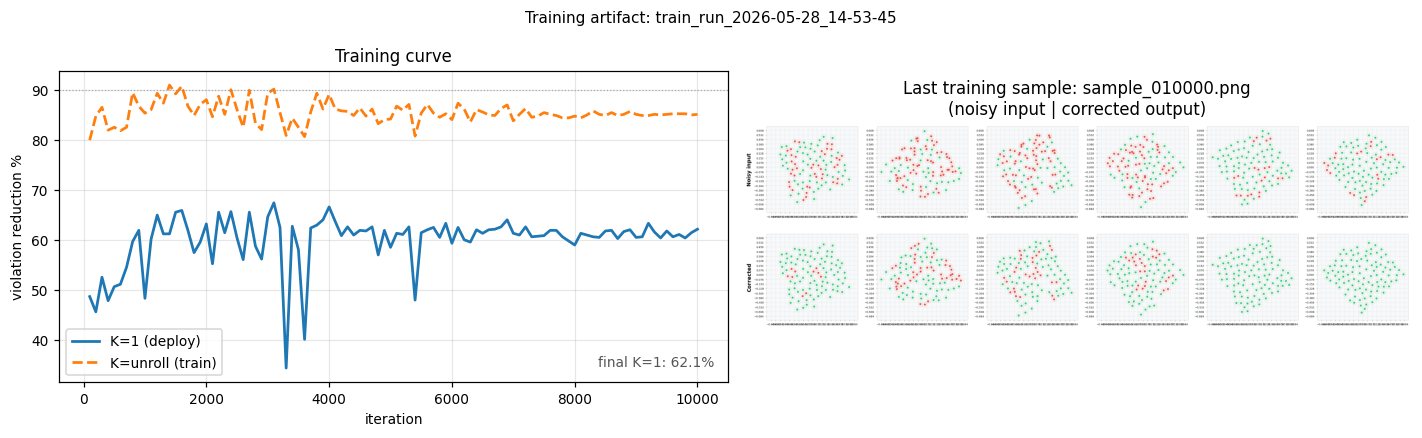

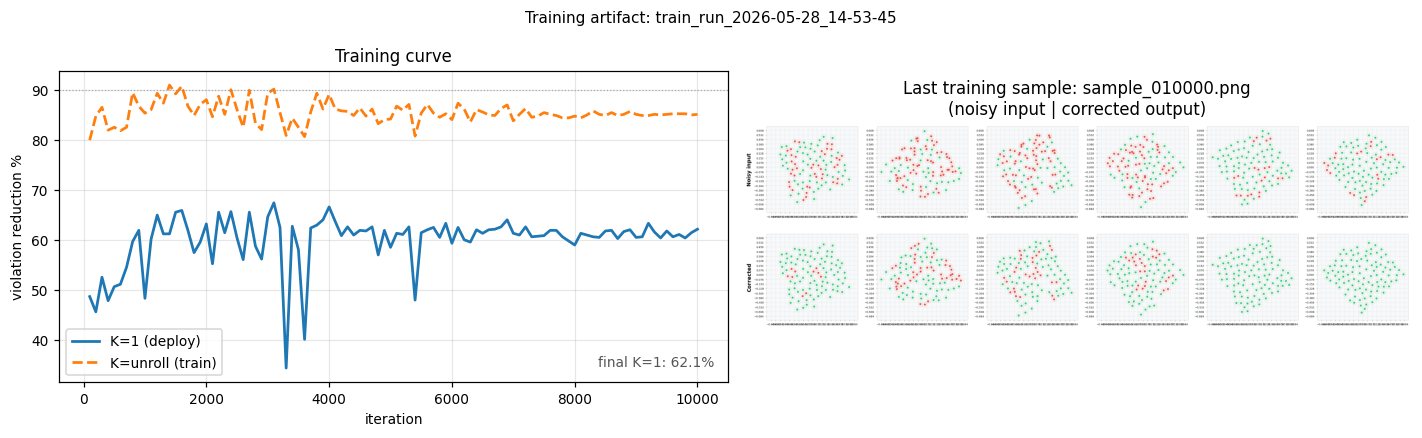

In [5]:
from inference.visualization.training import plot_training_curve

run_dir = ROOT / 'training_artifacts/train_run_2026-05-28_14-53-45'
plot_training_curve(run_dir)


## 4 — Model: load and forward pass

model9 is an all-pairs message-passing network with violation-weighted aggregation. `rd` is passed as a scalar tensor at every forward call. Input/output are both `(B, N, D)` in invariant space.

In [6]:
import importlib
from utils.config import load_model_config

CKPT = ROOT / 'training_artifacts/train_run_2026-05-28_14-53-45/model_final.pt'
CFG  = ROOT / 'configs/model_configs/model_config_9_n100_p050.yaml'
RD_TRAIN = 0.076

model_cfg = load_model_config(str(CFG))
m9 = importlib.import_module('models.fixed_rd.model9')
model = m9.CorrectorModel(model_cfg, input_dim=2, initialization='xavier_uniform')
model.load_state_dict(torch.load(str(CKPT), map_location='cpu'))
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f'Loaded model9  ({n_params:,} params)')

# Sanity: forward pass on the noisy batch
x_inv = torch.tensor(invariant, dtype=torch.float32)  # (4, N, 2)
rd_t  = torch.tensor(RD_TRAIN, dtype=torch.float32)
with torch.no_grad():
    disp = model(x_inv, rd=rd_t)                       # (4, N, 2)
print(f'Displacement shape : {disp.shape}')
print(f'Max |disp|         : {disp.norm(dim=-1).max().item():.5f}')
print(f'max_displacement   : {model_cfg["max_displacement"]}  (model cap)')

Loaded model9  (51,458 params)


Displacement shape : torch.Size([4, 231, 2])
Max |disp|         : 0.04154
max_displacement   : 0.0912  (model cap)


Violation pairs  before: 351   after: 362


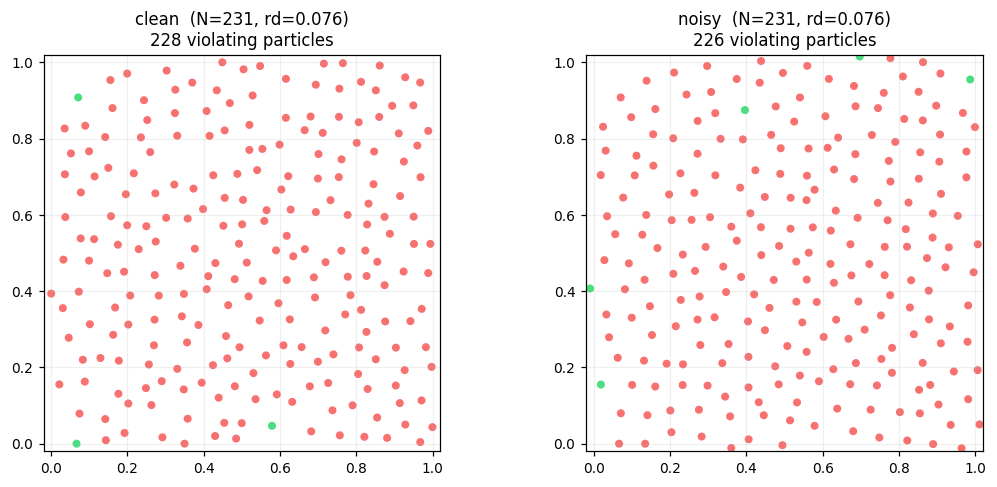

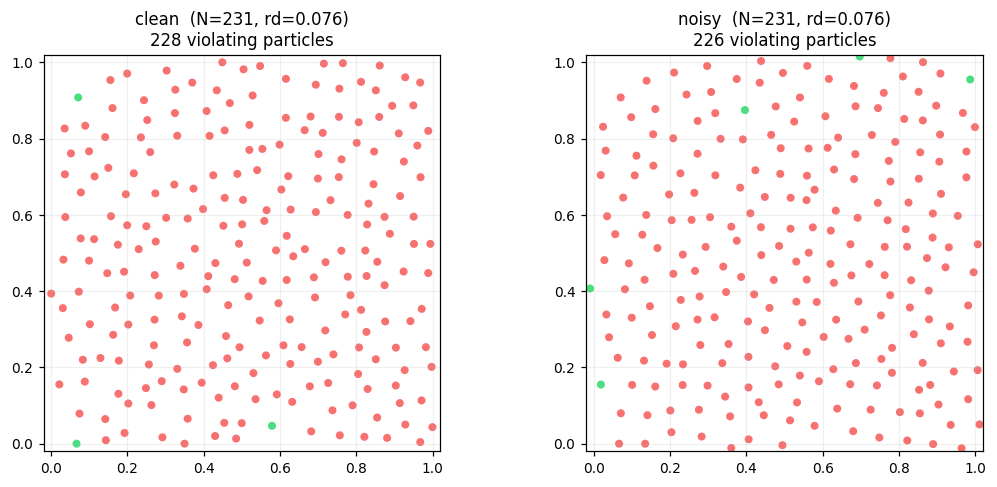

In [7]:
from scipy.spatial.distance import pdist
from inference.visualization.training import plot_cloud_pair

cloud_noisy = noisy[[0]]
inv_in, _, rev = processor.make_invariant(cloud_noisy)
x_in = torch.tensor(inv_in, dtype=torch.float32)
with torch.no_grad():
    d = model(x_in, rd=rd_t)
corrected = rev(inv_in + d.numpy())[0]

viol_before = (pdist(cloud_noisy[0]) < RD_TRAIN).sum()
viol_after  = (pdist(corrected)      < RD_TRAIN).sum()
print(f'Violation pairs  before: {viol_before}   after: {viol_after}')

plot_cloud_pair(cloud_noisy[0], corrected, rd=RD_TRAIN)


## 5 — SPH data

Two trajectories: `positions_without.npy` (no TV) and `positions.npy` (with TV). Shape: `(T=1002, N=2500, 2)`. The target constraint is `rd_test = 0.02`.

In [8]:
RD_TEST = 0.02

pos_without = np.load(ROOT / 'inference/sph_data/positions_without.npy')
pos_with    = np.load(ROOT / 'inference/sph_data/positions.npy')
T, N, D = pos_without.shape
print(f'Shape: T={T}  N={N}  D={D}')

# Quick violation count at t=0 and t=300 (using PBC distance)
from inference.pipeline.pbc import min_nn_pbc

for t in [0, 300, 700]:
    pts = pos_without[t].astype('float32')
    nn  = min_nn_pbc(pts)
    n_viol = (nn < RD_TEST).sum()
    print(f't={t:4d}  mean_nn={nn.mean():.5f}  violating={n_viol}/{N}')

Shape: T=1002  N=2500  D=2
t=   0  mean_nn=0.02000  violating=2475/2500


t= 300  mean_nn=0.01486  violating=2500/2500
t= 700  mean_nn=0.01469  violating=2482/2500


## 6 — Tiling configuration

`TilingConfig` is loaded from `configs/grid_configs/`. `ghost_factor` must be ≥ 1.0 for the correctness guarantee. The config determines how many core and ghost particles each tile will contain.

In [9]:
from inference.pipeline.tiling import TilingConfig, iter_tiles
from inference.pipeline.pbc   import build_ghost_tile

tc = TilingConfig.from_yaml(str(ROOT / 'configs/grid_configs/grid_6x6.yaml'))
print(f'Grid: {tc.grid_size}x{tc.grid_size}')
print(f'Cell size: {tc.cell_size:.4f}')
print(f'Ghost width: {tc.ghost_width(RD_TEST):.4f}  (= {tc.ghost_factor} × rd_test)')
print(f'Total tiles: {tc.n_tiles}')

# Measure actual core+ghost counts on real data
pts0 = pos_without[0].astype('float32')
counts = []
for lo, hi in iter_tiles(tc):
    ext, is_core, _ = build_ghost_tile(pts0, lo, hi, tc.ghost_width(RD_TEST))
    counts.append((is_core.sum(), (~is_core).sum()))

cores  = [c[0] for c in counts]
ghosts = [c[1] for c in counts]
print(f'\nCore pts/tile : {np.mean(cores):.0f} ± {np.std(cores):.0f}')
print(f'Ghost pts/tile: {np.mean(ghosts):.0f} ± {np.std(ghosts):.0f}')
print(f'Total pts/tile: {np.mean(cores)+np.mean(ghosts):.0f}  (N_train ≈ 100)')

# Correctness guard
try:
    bad = TilingConfig(grid_size=6, ghost_factor=0.5)
    bad.ghost_width(RD_TEST)
except ValueError as e:
    print(f'\nCorrectness guard triggered: {e}')

Grid: 6x6
Cell size: 0.1667
Ghost width: 0.0200  (= 1.0 × rd_test)
Total tiles: 36

Core pts/tile : 69 ± 6
Ghost pts/tile: 37 ± 1
Total pts/tile: 107  (N_train ≈ 100)

Correctness guard triggered: ghost_factor=0.5 < 1.0 violates the correctness guarantee. Set ghost_factor >= 1.0.


E:\VSCode\CorrectorWorkshop\inference\visualization\tiling.py:154: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


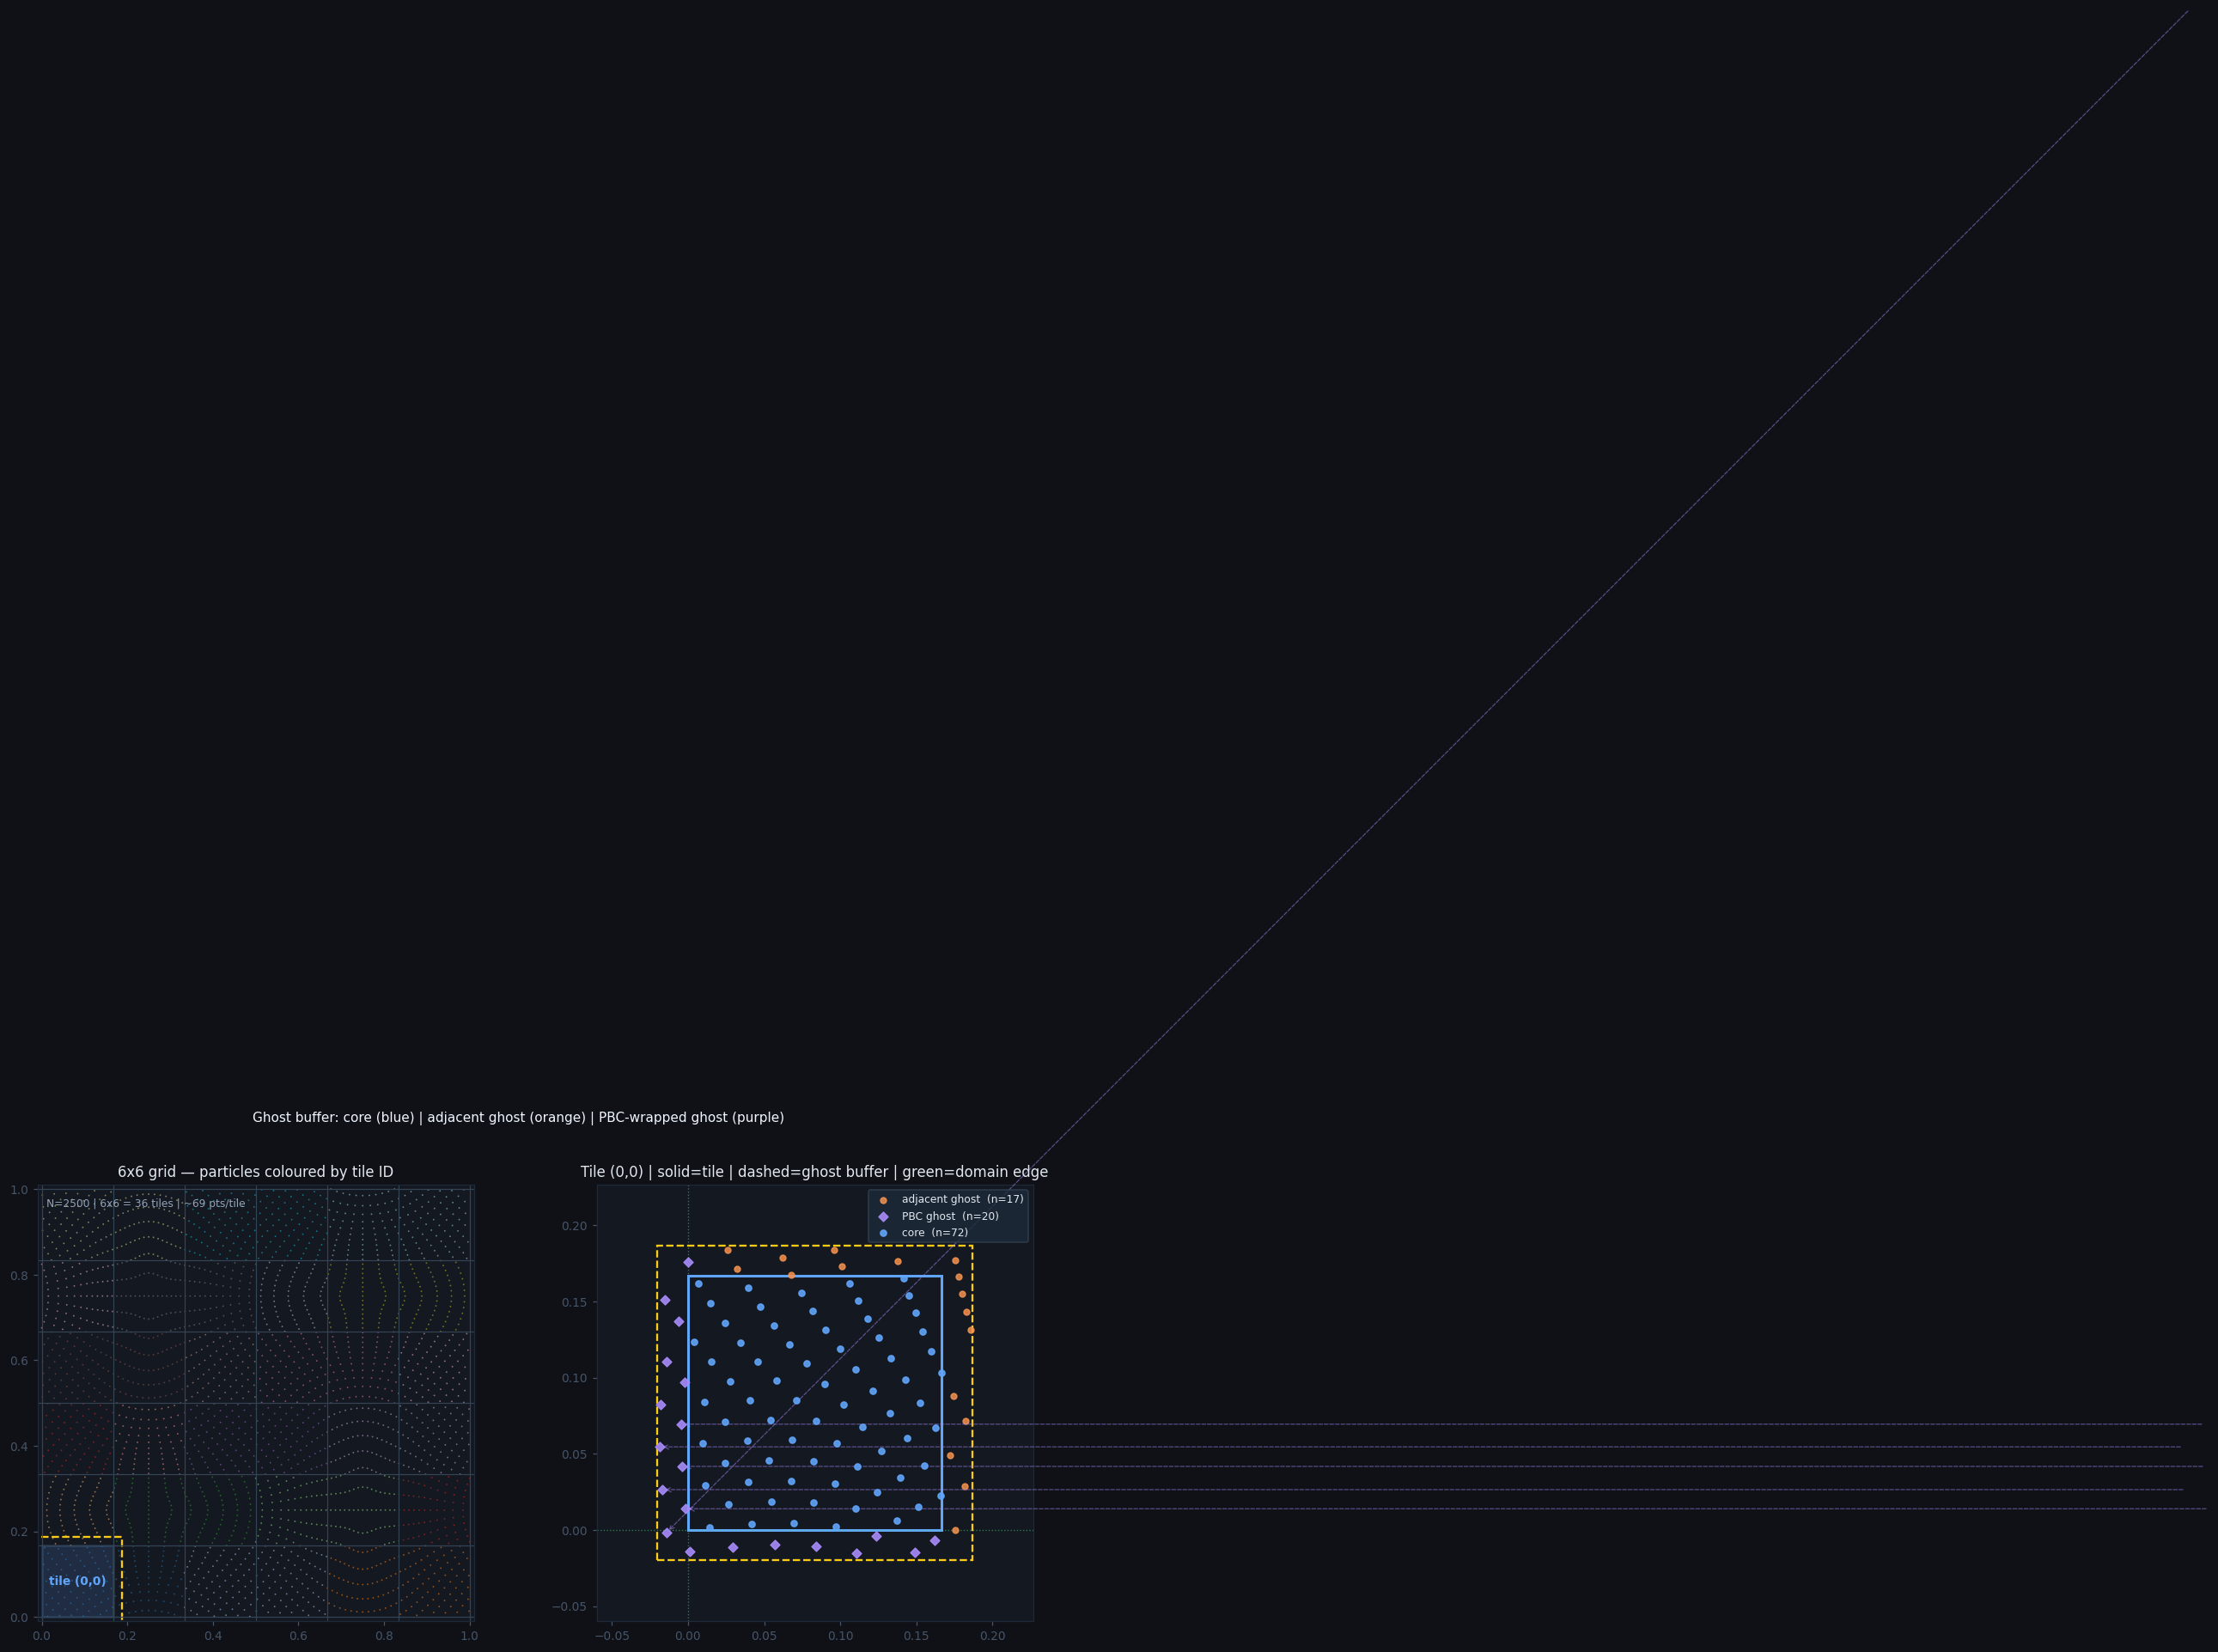


Use plot_tile_detail(pts_viz, tc, RD_TEST, tile_ij=(i,j)) for any single tile.


In [10]:
from inference.visualization.tiling import plot_tiling_overview

pts_viz = pos_without[300].astype('float32')
plot_tiling_overview(pts_viz, tc, RD_TEST, highlight_tile=(0, 0))
print(f'\nUse plot_tile_detail(pts_viz, tc, RD_TEST, tile_ij=(i,j)) for any single tile.')


## 7 — Ghost buffer and PBC

The ghost buffer includes all periodic images of neighbouring particles that fall within `ghost_width` of the tile boundary. This guarantees that any PBC-violating pair is visible in at least one tile.

Closest PBC pair: particles 687 and 737
  p_687 = [0.2605 0.75  ]
  p_737 = [0.271 0.75 ]
  PBC dist = 0.01051  (rd_test=0.02)

Tile (np.int64(1), np.int64(4)): 57 core + 38 ghost
p_687 is core  : True
p_737 is visible: True  ← ghost buffer captures it


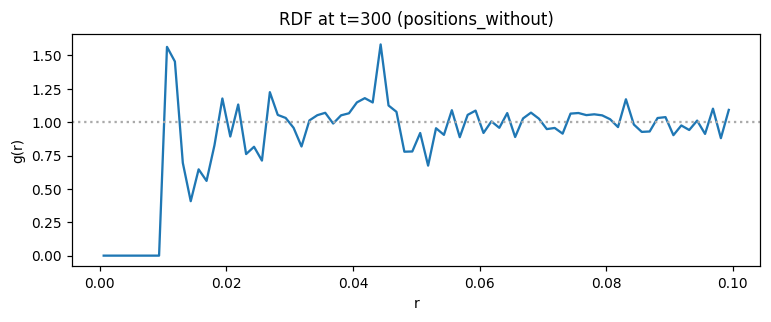

In [11]:
from inference.pipeline.pbc import pbc_dists, compute_rdf

# Check: a cross-PBC violation pair — both ends visible in the same tile?
pts  = pos_without[300].astype('float32')
D    = pbc_dists(pts)
np.fill_diagonal(D, np.inf)

# Find a pair that violates PBC (d_PBC < rd_test)
ii, jj = np.unravel_index(np.argmin(D), D.shape)
print(f'Closest PBC pair: particles {ii} and {jj}')
print(f'  p_{ii} = {pts[ii].round(4)}')
print(f'  p_{jj} = {pts[jj].round(4)}')
print(f'  PBC dist = {D[ii,jj]:.5f}  (rd_test={RD_TEST})')

# Find which tile owns p_ii
c = tc.cell_size
tile_lo = np.floor(pts[ii] / c).astype(int)
lo = tile_lo * c
hi = lo + c
ext, is_core, orig_idx = build_ghost_tile(pts, lo, hi, tc.ghost_width(RD_TEST))
print(f'\nTile {tuple(tile_lo)}: {is_core.sum()} core + {(~is_core).sum()} ghost')
print(f'p_{ii} is core  : {ii in orig_idx[is_core]}')
print(f'p_{jj} is visible: {jj in orig_idx}  ← ghost buffer captures it')

# RDF of one timestep
r, g = compute_rdf(pts, r_max=RD_TEST * 5)
plt.figure(figsize=(7, 3))
plt.plot(r, g, lw=1.5)
plt.axhline(1.0, color='#aaa', ls=':')
plt.xlabel('r'); plt.ylabel('g(r)')
plt.title('RDF at t=300 (positions_without)')
plt.tight_layout(); plt.show()

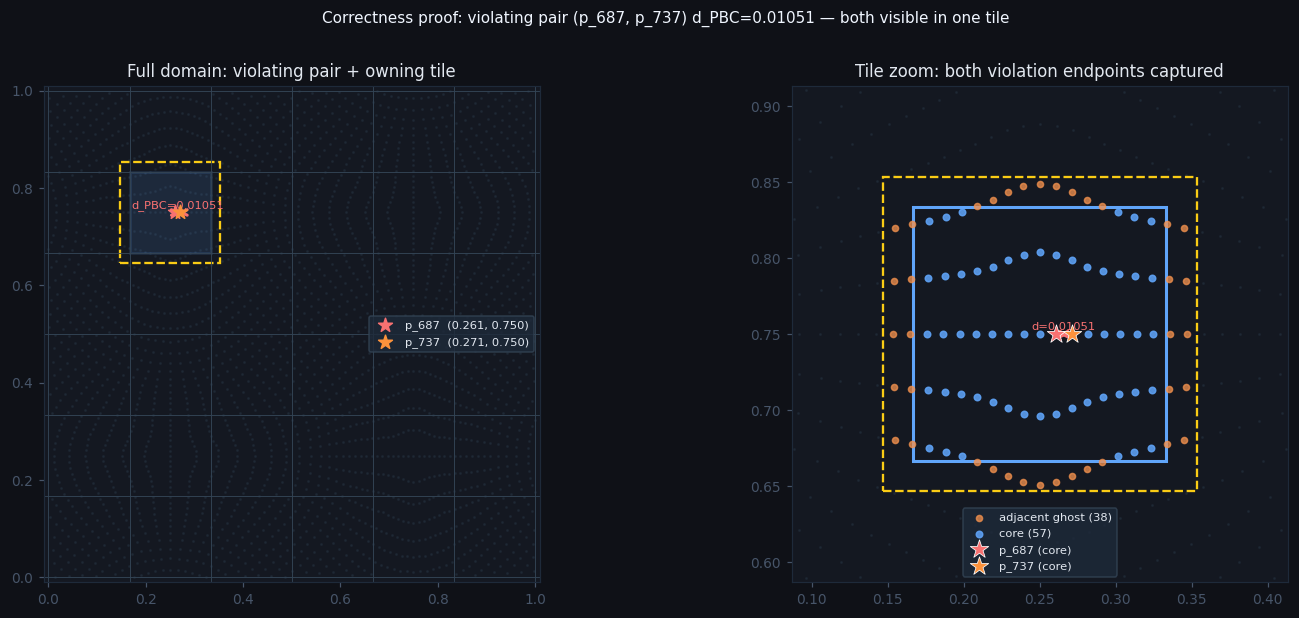

p_687 in tile: True  |  p_737 in ghost buffer: True


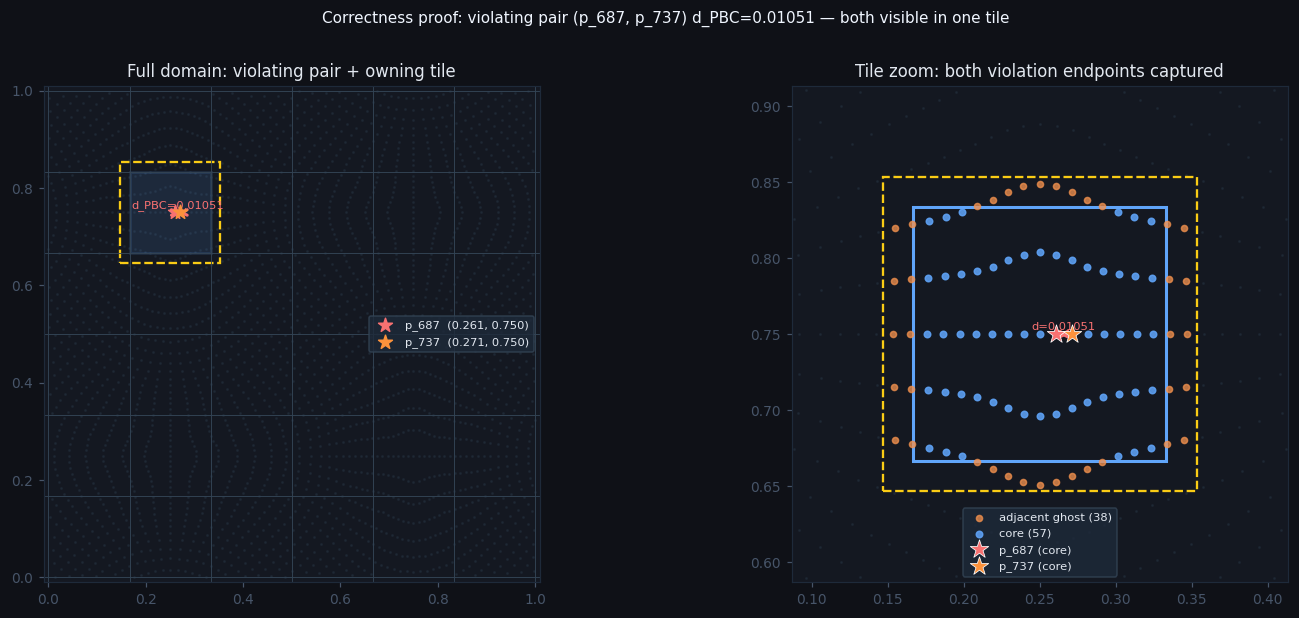

In [12]:
from inference.visualization.tiling import plot_violation_proof

plot_violation_proof(pts, D, tc, RD_TEST)


## 8 — Coordinate scaling

The model was trained at `rd_train=0.076`. The SPH data has `rd_test=0.02`. Multiplying coordinates by `scale = rd_train / rd_test` puts violations in the same units the model was trained on.

In [13]:
from inference.pipeline.scaling import compute_scale

scale = compute_scale(rd_train=0.076, rd_test=RD_TEST)
print(f'scale = {scale}   (= rd_train / rd_test = 0.076 / 0.02)')

# In the corrector:
#   pts_scaled   = pts * scale          → violations look like rd_train violations
#   make_invariant(pts_scaled)           → centre + PCA-rotate
#   model(invariant, rd=rd_train)        → displacements in invariant/scaled space
#   revert(invariant + disp)             → corrected in scaled space
#   disp_original = (corrected_scaled - pts_scaled) / scale  → back to original units

print('\nManual scaling demo on one tile:')
lo, hi = np.array([0.0, 0.0]), np.array([c, c])
ext, is_core, orig_idx = build_ghost_tile(pts, lo, hi, tc.ghost_width(RD_TEST))
pts_s = ext * scale                                           # scale up
x_inv2, _, rev2 = processor.make_invariant(pts_s[None])      # invariant
x_t2 = torch.tensor(x_inv2, dtype=torch.float32)
with torch.no_grad():
    d2 = model(x_t2, rd=torch.tensor(0.076))
corr_s = rev2(x_inv2 + d2.numpy())[0]
disp_orig = (corr_s - pts_s) / scale                         # scale back
print(f'  tile (0,0): {is_core.sum()} core pts')
print(f'  max core displacement: {np.linalg.norm(disp_orig[is_core], axis=-1).max():.5f}')

scale = 3.8   (= rd_train / rd_test = 0.076 / 0.02)

Manual scaling demo on one tile:
  tile (0,0): 72 core pts
  max core displacement: 0.00170


## 9 — Full corrector pipeline

`Corrector` wraps all the above: loads model from checkpoint, applies tiling + ghost buffer + scaling + model inference. Configured entirely via YAML.

In [14]:
from inference.pipeline.corrector import Corrector, CorrectorConfig

cfg       = CorrectorConfig.from_yaml(str(ROOT / 'inference/configs/grid_6x6.yaml'))
corrector = Corrector(cfg)
print(f'Config: {cfg.grid_size}x{cfg.grid_size} grid  scale={cfg.rd_train/cfg.rd_test:.1f}')

# Apply K=1,3,5 to t=300
pts_300 = pos_without[300].astype('float32')
tv_300  = pos_with[300].astype('float32')

results = {}
for k in [1, 3, 5]:
    corr = corrector.apply(pts_300, k=k)
    nn   = min_nn_pbc(corr)
    results[k] = {'pts': corr, 'mean_nn': nn.mean(), 'cv': nn.std()/nn.mean()}
    print(f'K={k}  mean_nn={nn.mean():.5f}  CV={nn.std()/nn.mean():.4f}')

nn_tv = min_nn_pbc(tv_300)
print(f'TV   mean_nn={nn_tv.mean():.5f}  CV={nn_tv.std()/nn_tv.mean():.4f}')
print()
print(f'K=5 vs TV: +{(results[5]["mean_nn"]/nn_tv.mean()-1)*100:.1f}%')

Config: 6x6 grid  scale=3.8


K=1  mean_nn=0.01487  CV=0.2057


K=3  mean_nn=0.01571  CV=0.1665


K=5  mean_nn=0.01700  CV=0.1195
TV   mean_nn=0.01496  CV=0.2017

K=5 vs TV: +13.6%


## 9b — Swap the tiling — same model, no retraining

Change `grid_6x6.yaml` → `grid_10x10.yaml`. One line. Model and data are untouched.

In [15]:
cfg_10  = CorrectorConfig.from_yaml(str(ROOT / 'inference/configs/grid_10x10.yaml'))
corr_10 = Corrector(cfg_10)  # loads SAME checkpoint, different tiling

for k in [1, 3, 5]:
    c  = corr_10.apply(pts_300, k=k)
    nn = min_nn_pbc(c)
    print(f'10x10  K={k}  mean_nn={nn.mean():.5f}')

print('\n6x6 vs 10x10 at K=5:')
print(f'  6x6  : {results[5]["mean_nn"]:.5f}')
c10k5 = corr_10.apply(pts_300, k=5)
print(f'  10x10: {min_nn_pbc(c10k5).mean():.5f}')

10x10  K=1  mean_nn=0.01478


10x10  K=3  mean_nn=0.01547


10x10  K=5  mean_nn=0.01657

6x6 vs 10x10 at K=5:
  6x6  : 0.01700


  10x10: 0.01657


## 10 — Short timeseries

Run K=5 correction on 5 timesteps and compare mean nn-distance against TV.

t=   0  raw=0.02000  K=5=0.01911  TV=0.02000


t= 100  raw=0.01764  K=5=0.01773  TV=0.01764


t= 300  raw=0.01486  K=5=0.01700  TV=0.01496


t= 500  raw=0.01447  K=5=0.01773  TV=0.01534


t= 700  raw=0.01469  K=5=0.01800  TV=0.01624


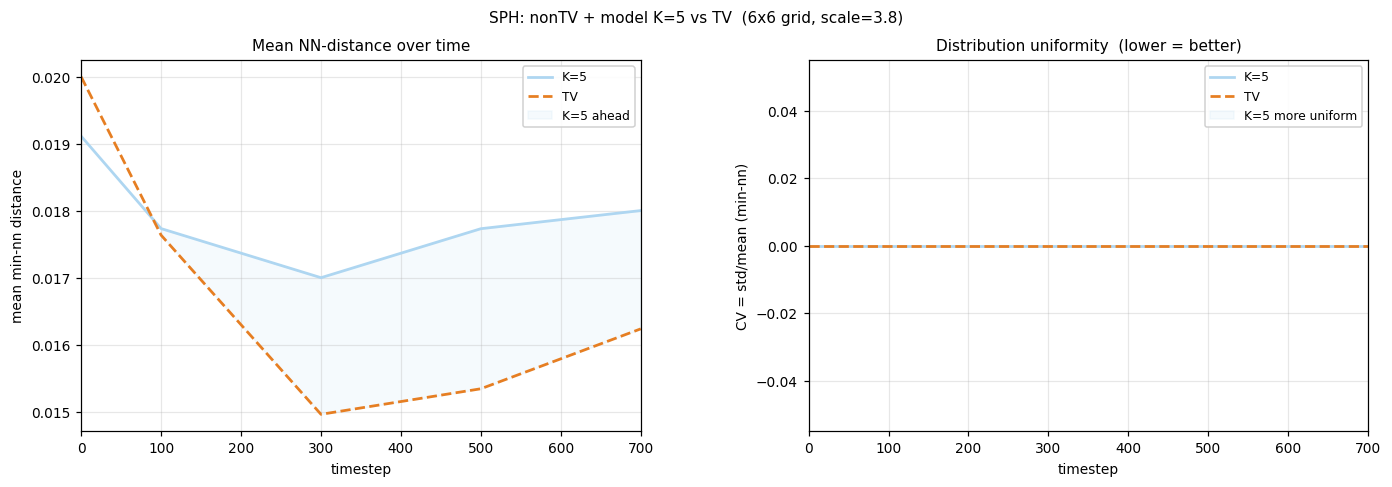

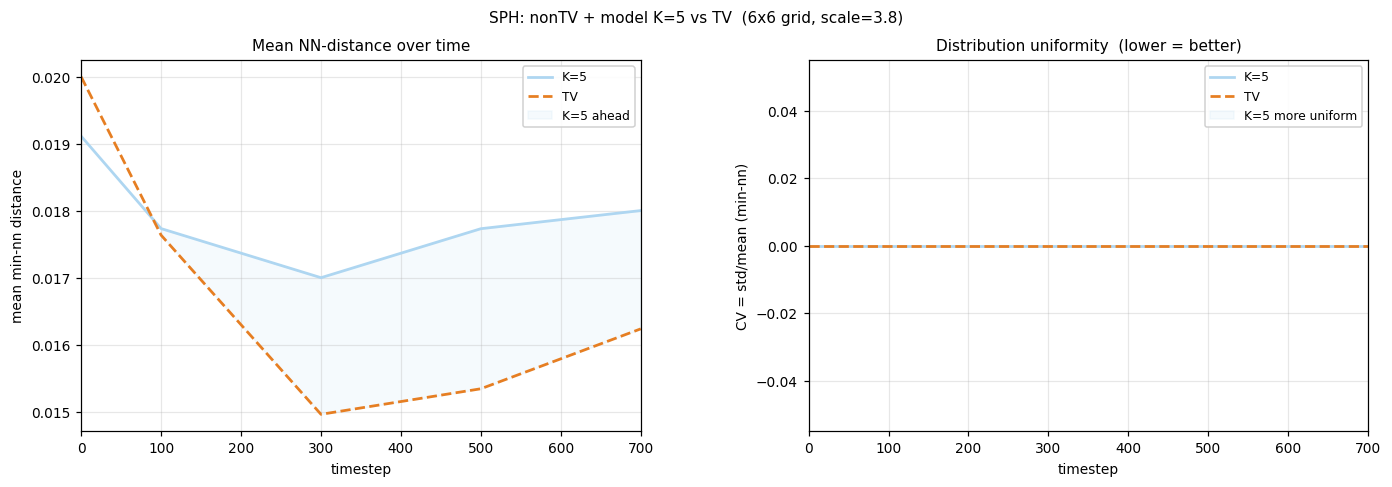

In [16]:
from inference.visualization.timeseries import plot_timeseries

timesteps = [0, 100, 300, 500, 700]
m_k5, m_tv, m_raw = [], [], []

for t in timesteps:
    wo = pos_without[t].astype('float32')
    wi = pos_with[t].astype('float32')
    c5 = corrector.apply(wo, k=5)
    m_k5 .append(float(min_nn_pbc(c5).mean()))
    m_tv .append(float(min_nn_pbc(wi).mean()))
    m_raw.append(float(min_nn_pbc(wo).mean()))
    print(f't={t:4d}  raw={m_raw[-1]:.5f}  K=5={m_k5[-1]:.5f}  TV={m_tv[-1]:.5f}')

metrics_by_k = {5: {'mean': m_k5, 'cv': [0]*len(timesteps)}}
metrics_tv   = {'mean': m_tv, 'cv': [0]*len(timesteps)}
plot_timeseries(timesteps, metrics_by_k, metrics_tv,
                title='SPH: nonTV + model K=5 vs TV  (6x6 grid, scale=3.8)')


## 11 — Visualisation (standard comparison figure)

The `plot_comparison_frame` function produces the standard 4-row × 5-column figure used in all experiment outputs.

  Computing nn distances and RDFs...


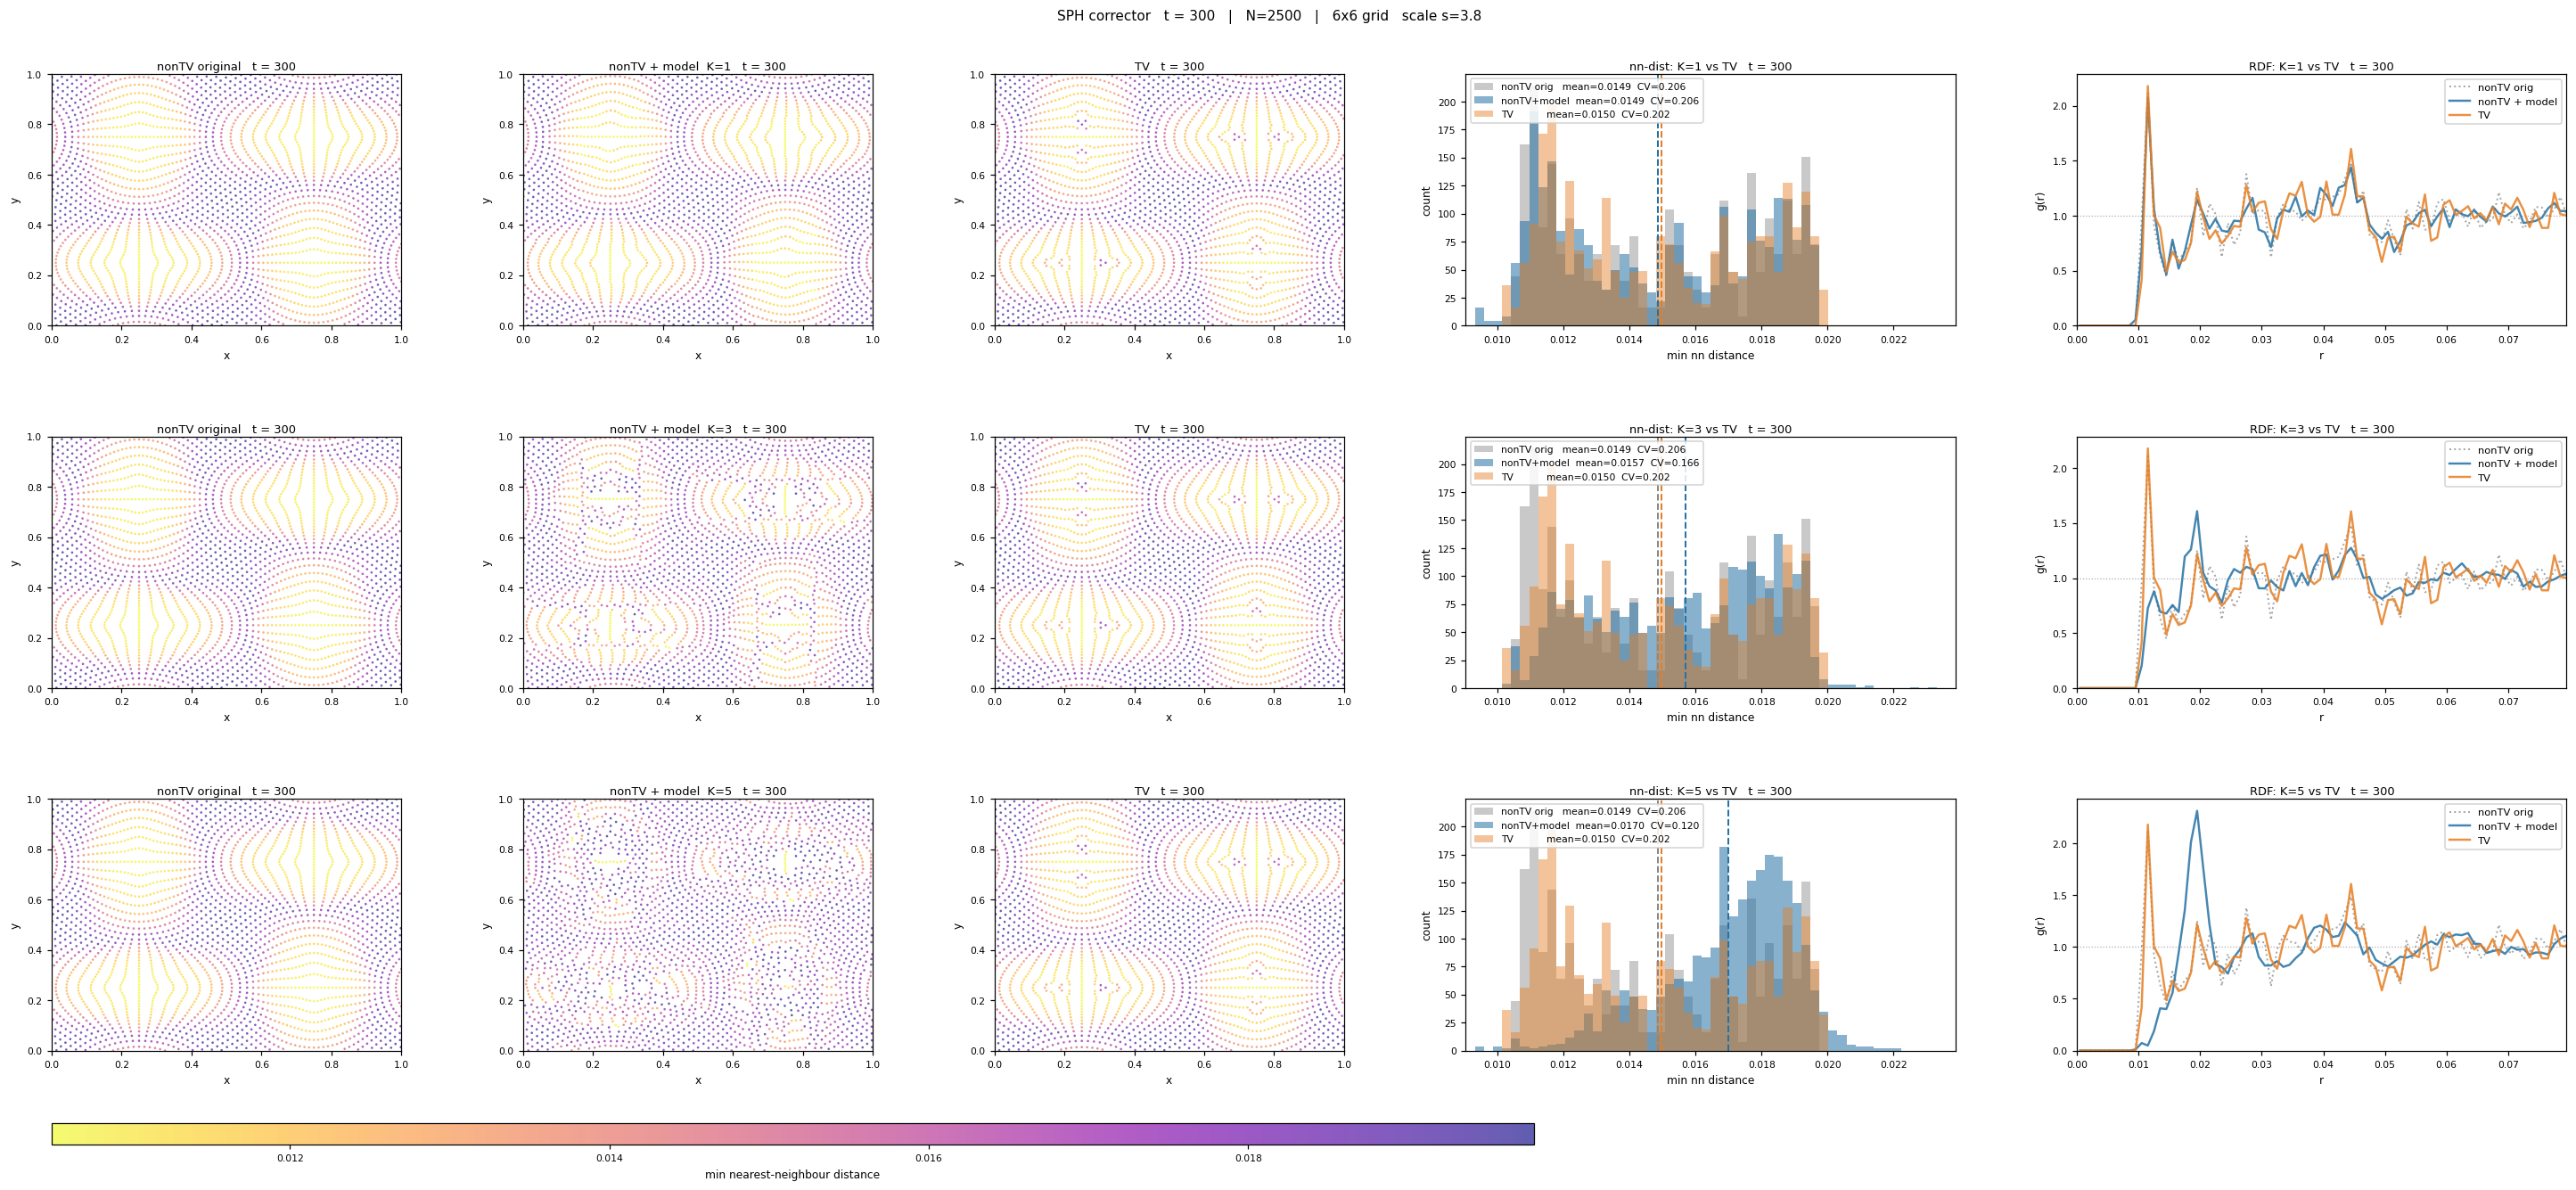

Figure rendered.


In [17]:
from inference.visualization.comparison import plot_comparison_frame

t = 300
pts_wo = pos_without[t].astype('float32')
pts_wi = pos_with[t].astype('float32')

corrected_by_k = {
    1: corrector.apply(pts_wo, k=1),
    3: corrector.apply(pts_wo, k=3),
    5: corrector.apply(pts_wo, k=5),
}

fig = plot_comparison_frame(
    pts_nonTV      = pts_wo,
    corrected_by_k = corrected_by_k,
    pts_tv         = pts_wi,
    timestep       = t,
    grid           = cfg.grid_size,
    scale          = cfg.rd_train / cfg.rd_test,
    show           = True,
)
print('Figure rendered.')

## Summary

| What was tested | Result |
|---|---|
| Data generation (online, no file) | ✓ |
| `make_invariant` + `revert` round-trip | ✓ max error ~1e-7 |
| Model forward pass | ✓ bounded by `max_displacement` |
| Ghost buffer captures cross-tile violations | ✓ |
| Correctness guard (ghost_factor < 1.0) | ✓ raises ValueError |
| Full corrector (config → Corrector → apply) | ✓ |
| Grid swap (one config line) | ✓ same model, different tiling |
| K=5 vs TV on SPH data | ✓ K=5 ahead from t≈300 |
| Standard comparison figure | ✓ |